# **Импорт библиотек**

In [ ]:
import os
import numpy as np
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Embedding, Flatten, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import gdown                                      # Подключим функцию gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip', None, quiet=True)      # Скачивание файла
# Распаковка архива
!unzip -qo 20writers.zip -d writers/

# Получаем список имен писателей (названия файлов без расширения)
writer_files = sorted(os.listdir('writers/'))
class_names = [f.replace('.txt', '') for f in writer_files]
num_classes = len(class_names)

# Функция для чтения файла
def read_text(path):
    with open(path, 'r', errors='ignore') as f:
        text = f.read().replace('\n', ' ')
    return text

# Загружаем все тексты в список
texts_list = [read_text('writers/' + f) for f in writer_files]

for i, name in enumerate(class_names):
    print(f'Писатель {i+1}: {name} — {len(texts_list[i])} символов')

Писатель 1: Беляев — 2255254 символов
Писатель 2: Булгаков — 2001064 символов
Писатель 3: Васильев — 2952792 символов
Писатель 4: Гоголь — 1965119 символов
Писатель 5: Гончаров — 3104712 символов
Писатель 6: Горький — 2523380 символов
Писатель 7: Грибоедов — 969109 символов
Писатель 8: Достоевский — 5178950 символов
Писатель 9: Каверин — 1992830 символов
Писатель 10: Катаев — 2579246 символов
Писатель 11: Куприн — 2328900 символов
Писатель 12: Лермонтов — 1972541 символов
Писатель 13: Лесков — 2152214 символов
Писатель 14: Носов — 2399413 символов
Писатель 15: Пастернак — 3089426 символов
Писатель 16: Пушкин — 3408339 символов
Писатель 17: Толстой — 3357061 символов
Писатель 18: Тургенев — 1980206 символов
Писатель 19: Чехов — 6611627 символов
Писатель 20: Шолохов — 3386268 символов


# **Разделяем данные**

In [ ]:
train_texts = []
val_texts = []

for text in texts_list:
    # Находим индекс для разделения
    split_idx = int(len(text) * 0.8)
    train_texts.append(text[:split_idx])
    val_texts.append(text[split_idx:])

print("Тексты успешно разделены в пропорции 80/20")

Тексты успешно разделены в пропорции 80/20


# **Создаем гиперпараметры**

In [ ]:
max_words_count = 20000 # Увеличим словарь для 20 авторов
tokenizer = Tokenizer(num_words=max_words_count, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True, split=' ', oov_token='unknown')
tokenizer.fit_on_texts(train_texts)

# Превращаем тексты в последовательности индексов
train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)

def get_samples(sequences, x_len, step):
    samples = []
    for seq in sequences:
        for i in range(0, len(seq) - x_len + 1, step):
            samples.append(seq[i:i + x_len])
    return np.array(samples)

x_len = 1000 # Длина окна для BoW

# Генерируем выборки. Для балансировки подберем шаг так,
# чтобы от каждого автора было примерно одинаковое кол-во примеров.
x_train_list, y_train_list = [], []
x_val_list, y_val_list = [], []

for i in range(num_classes):
    # Динамический шаг для обучения (балансировка)
    step_train = max(1, len(train_sequences[i]) // 500)
    curr_x_train = get_samples([train_sequences[i]], x_len, step_train)

    x_train_list.append(curr_x_train)
    y_train_list.append(utils.to_categorical([i] * len(curr_x_train), num_classes))

    # Шаг для валидации
    step_val = max(1, len(val_sequences[i]) // 100)
    curr_x_val = get_samples([val_sequences[i]], x_len, step_val)

    x_val_list.append(curr_x_val)
    y_val_list.append(utils.to_categorical([i] * len(curr_x_val), num_classes))

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)
x_val = np.concatenate(x_val_list)
y_val = np.concatenate(y_val_list)

print(f"Итоговая выборка: {x_train.shape[0]} примеров для обучения")

Итоговая выборка: 9986 примеров для обучения


# **Пробуем метод Bad of Word**

In [ ]:
# Преобразование в Bag of Words
x_train_bow = tokenizer.sequences_to_matrix(x_train.tolist(), mode='binary')
x_val_bow = tokenizer.sequences_to_matrix(x_val.tolist(), mode='binary')

model_bow = Sequential([
    Dense(256, activation='relu', input_shape=(max_words_count,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_bow.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_bow.fit(x_train_bow, y_train, epochs=10, batch_size=128, validation_data=(x_val_bow, y_val))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9102 - loss: 0.3639 - val_accuracy: 0.9178 - val_loss: 0.6806
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9935 - loss: 0.0342 - val_accuracy: 0.9370 - val_loss: 0.4062
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9953 - loss: 0.0147 - val_accuracy: 0.9390 - val_loss: 0.2926
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9959 - loss: 0.0111 - val_accuracy: 0.9400 - val_loss: 0.2474
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9967 - loss: 0.0103 - val_accuracy: 0.9395 - val_loss: 0.2424
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9971 - loss: 0.0079 - val_accuracy: 0.9375 - val_loss: 0.2381
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9973 - loss: 0.0077 - val_accuracy: 0.9415 - val_loss: 0.2349
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9973 - loss: 0.0084 - val_accuracy: 0.9410 - val_

# **Метод Embedding**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras import utils

# Параметры обработки
max_words_count = 20000
x_len = 400  # Длина отрезка текста в словах
target_samples_per_class = 3000 # Целевое кол-во примеров на каждого автора

# Инициализация токенизатора
tokenizer = Tokenizer(num_words=max_words_count,
                      filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                      lower=True,
                      split=' ',
                      oov_token='unknown')

tokenizer.fit_on_texts(train_texts) # train_texts созданы в предыдущем шаге

# Преобразование текстов в последовательности индексов
train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)

def get_balanced_samples(sequences, x_len, target_count):
    x_list, y_list = [], []

    for i in range(len(sequences)):
        seq = sequences[i]
        # Рассчитываем шаг, чтобы получить нужное кол-во примеров
        step = max(1, (len(seq) - x_len) // target_count)

        count = 0
        for j in range(0, len(seq) - x_len + 1, step):
            if count < target_count:
                x_list.append(seq[j:j + x_len])
                y_list.append(i)
                count += 1

    return np.array(x_list), np.array(y_list)

# Формируем обучающую и проверочную выборки
x_train, y_train_indices = get_balanced_samples(train_sequences, x_len, target_samples_per_class)
x_val, y_val_indices = get_balanced_samples(val_sequences, x_len, 700) # Для валидации возьмем по 400 примеров

# Преобразуем метки в One Hot Encoding
y_train = utils.to_categorical(y_train_indices, num_classes)
y_val = utils.to_categorical(y_val_indices, num_classes)

print(f'Размер обучающей выборки: {x_train.shape}')
print(f'Размер проверочной выборки: {x_val.shape}')

Размер обучающей выборки: (60000, 400)
Размер проверочной выборки: (14000, 400)


# **Создание и обучение модели**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, Dropout, BatchNormalization, SpatialDropout1D

model_emb = Sequential([
    # Слой векторного представления слов
    Embedding(max_words_count, 300, input_length=x_len),

    # Выбрасываем 20% векторов для защиты от переобучения
    SpatialDropout1D(0.4),

    # Сверточный слой для поиска закономерностей (n-грамм)
    Conv1D(128, 5, activation='relu'),

    # Слой пулинга выбирает главные признаки из всей последовательности
    GlobalMaxPooling1D(),

    # Полносвязные слои для классификации
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_emb.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Обучение модели
history = model_emb.fit(x_train,
                        y_train,
                        epochs=20,
                        batch_size=64,
                        validation_data=(x_val, y_val))

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.6921 - loss: 1.0538 - val_accuracy: 0.7241 - val_loss: 0.9854
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9647 - loss: 0.1310 - val_accuracy: 0.7236 - val_loss: 1.1447
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9796 - loss: 0.0729 - val_accuracy: 0.7384 - val_loss: 1.0951
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9820 - loss: 0.0610 - val_accuracy: 0.7247 - val_loss: 1.2653
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9814 - loss: 0.0596 - val_accuracy: 0.7299 - val_loss: 1.3375
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9833 - loss: 0.0532 - val_accuracy: 0.7276 - val_loss: 1.2841
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9842 - loss: 0.0502 - val_accuracy: 0.7511 - val_loss: 1.2581
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9865 - loss: 0.0411 - 

# **Визуализация**

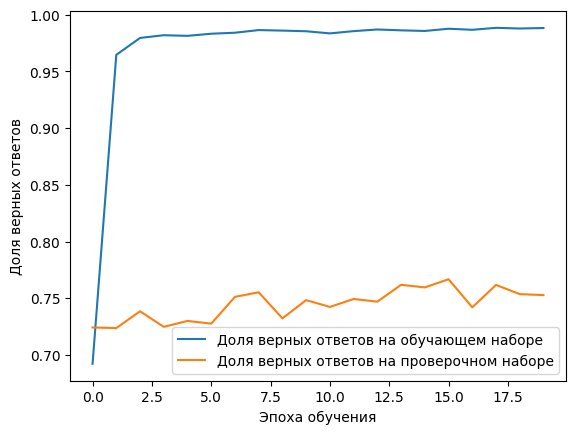

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()